# Part 2: Simple RNN

**Owner:** Honourgod Kilechukwu Levison

This notebook is my part of the group project on vaccine sentiment analysis, and it builds the first recurrent model in the comparison: a network arranged as an embedding layer, a SimpleRNN layer, and a single linear output unit. The idea is to let the model read a tweet the way a person would, one token at a time in the order it was written, and predict where the tweet sits on the sentiment scale used for this challenge, from -1 (negative, anti-vaccine) to +1 (positive, pro-vaccine). It uses the shared train and validation split created in notebook 01 and the same text cleaning Fred chose from his exploratory analysis, so the RMSE reported here can be compared directly with the other four models once they are finished.

| Output | Path |
|---|---|
| Validation predictions | `results/rnn_validation_predictions.csv` |
| Experiment log | `results/experiments/rnn_experiments.csv` |
| Figures | `results/figures/rnn_*.png` |
| Final model | `models/simple_rnn.keras` (+ `models/simple_rnn_vectorizer.json`) |

## 1. Setup

In [1]:
# Setup: works on Google Colab and locally.
import subprocess
import sys
from pathlib import Path

REPO = "vaccine-sentiment-sequential-models"
if "google.colab" in sys.modules:
    ROOT = Path("/content") / REPO
    if not ROOT.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        f"https://github.com/Adossi-design/{REPO}.git", str(ROOT)], check=True)
    else:  # already cloned: pull the latest commits
        subprocess.run(["git", "-C", str(ROOT), "pull", "--ff-only"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    str(ROOT / "requirements.txt")], check=True)
else:
    ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "common.py").exists())
sys.path.insert(0, str(ROOT))

from src import common

In [2]:
import json
import time

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from src.preprocess import prepare_series

tf.config.experimental.enable_op_determinism()  # keeps reruns identical on the same hardware and library versions

OWNER = "Honourgod Kilechukwu Levison"
MODEL = "rnn"
MAX_EPOCHS = 30  # upper bound; early stopping normally ends training much sooner
PATIENCE = 3  # epochs without a better validation loss before stopping
MIN_COUNT = 2  # a word needs this many training occurrences to get its own embedding
LOG_PATH = common.EXPERIMENTS_DIR / f"{MODEL}_experiments.csv"
common.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Figure style: kept the same as the other model notebooks so the figures read as one set.
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#8a8984"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 2, "savefig.dpi": 200, "savefig.bbox": "tight",
})

## 2. Cleaning the tweets

Notebook 01 already decided how the tweets should be cleaned, after looking closely at what makes this text difficult: HTML codes, curly quotes, stretched letters such as "sooo", hashtags that turn out to be strongly linked to one sentiment, and emojis that are sometimes the only place a feeling is expressed in an otherwise short tweet. Rather than repeating that reasoning or writing a second cleaning function, this notebook uses `prepare_series()` from `src/preprocess.py` directly, which is the whole point of keeping that function in a shared module: every model in the group reads the tweets after exactly the same transformation, so a difference in RMSE later reflects a difference between the models rather than a difference in how the text was prepared. The function lowercases the text, keeps hashtags, punctuation such as "!", "?" and "…", and emojis as their own tokens, shortens repeated letters, and always returns at least one token, using the placeholder `<empty>` for the rare tweet that has nothing left after cleaning.

In [3]:
PREPROCESSING = "prepare_series() from src/preprocess.py: the shared cleaning chosen in notebook 01 from the EDA"


def prepare_text(texts):
    """Return the shared cleaned tweets as a NumPy array of strings."""
    return prepare_series(texts).to_numpy()

## 3. Shared split

`common.load_train_validation()` returns exactly the rows listed in `splits/train_ids.csv` and `splits/validation_ids.csv`, the split notebook 01 created once for the whole group, and it fails loudly if those files are missing, overlap, or contain a label outside {-1, 0, 1}. This notebook does not create any split of its own, which matters because the RMSE reported here is only comparable to the other four models if everyone is scored on the same validation tweets.

Before training anything, it helps to know what a model that ignores the text entirely would score, because that number is the real floor every model has to beat. RMSE squares each error before averaging, so a negative tweet predicted as positive costs four times as much as one predicted as neutral, which means the metric already punishes the kind of large, confident mistake a model can make on this data.

In [4]:
train_df, val_df = common.load_train_validation()
train_text, val_text = prepare_text(train_df["safe_text"]), prepare_text(val_df["safe_text"])
y_train = train_df["label"].to_numpy(dtype="float32")
y_val = val_df["label"].to_numpy(dtype="float32")

print(f"{len(train_df):,} training and {len(val_df):,} validation tweets")
display(pd.DataFrame({
    "train share": train_df["label"].value_counts(normalize=True),
    "validation share": val_df["label"].value_counts(normalize=True),
}).sort_index().round(3))

CONSTANT_RMSE = common.rmse(y_val, np.full_like(y_val, y_train.mean()))
print(f"Always predicting the training mean ({y_train.mean():.3f}) gives validation RMSE {CONSTANT_RMSE:.4f}")

8,001 training and 1,999 validation tweets


,train share,validation share
label,,
-1.0,0.104,0.103
0.0,0.491,0.491
1.0,0.405,0.406


Always predicting the training mean (0.301) gives validation RMSE 0.6459


The shares on both sides of the split match closely (about 10% negative, 49% neutral and 41% positive on each side), which is what a good stratified split should look like and confirms the split is doing its job. Always predicting the training mean of 0.301 gives a validation RMSE of 0.6459, close to the 0.646 Fred reports in notebook 01 from the same calculation, and this is the number the Simple RNN has to beat clearly before its extra complexity can be called worthwhile.

## 4. Vocabulary and sequence length

Because `prepare_series()` already lowercases the text, keeps the placeholders `<user>` and `<url>`, and turns hashtags, punctuation and emojis into their own tokens, there is nothing left for Keras' `TextVectorization` layer to clean. Its only job here is to turn the already-prepared, space-separated tokens into integer ids, so it is built with `standardize=None` and `split="whitespace"`; using its default standardization instead would undo Fred's cleaning by stripping the "<", ">", "#", "!" and "…" characters that were deliberately kept. `TextVectorization` is adapted on the training tweets only, so the vocabulary and the sequence length are both decided without looking at the validation tweets.

A word seen only once in training gives the embedding layer a single example to learn from, which is not enough to learn anything reliable, so words below a minimum count are mapped to the single unknown token `[UNK]` instead. Notebook 01 found 12,776 distinct tokens in the training split and suggested keeping only the words that appear at least twice, which came to about 5,700; running the same count here on the tokens `prepare_series()` produces, since it wraps the same `tokenize()` function notebook 01 used, confirms that suggestion rather than replacing it.

In [5]:
STANDARDIZE = None
SPLIT = "whitespace"

full_vectorizer = keras.layers.TextVectorization(standardize=STANDARDIZE, split=SPLIT)
full_vectorizer.adapt(train_text)
train_ids_full = full_vectorizer(train_text).numpy()  # padded to the longest training tweet
counts = np.bincount(train_ids_full.ravel(), minlength=full_vectorizer.vocabulary_size())
lengths = (train_ids_full != 0).sum(axis=1)

n_words = full_vectorizer.vocabulary_size() - 2  # minus padding and [UNK]
n_kept = int((counts[2:] >= MIN_COUNT).sum())  # the vocabulary is sorted by frequency
MAX_TOKENS = n_kept + 2
print(f"{n_words:,} distinct training tokens; {n_kept:,} occur at least {MIN_COUNT} times, so MAX_TOKENS = {MAX_TOKENS:,}")
print(f"Words below the cut-off are {counts[2 + n_kept:].sum() / counts[2:].sum():.1%} of all training token occurrences")

percentiles = {f"p{q}": int(np.ceil(np.percentile(lengths, q))) for q in (50, 90, 95, 99)}
percentiles["max"] = int(lengths.max())
display(pd.DataFrame([percentiles], index=["tokens per training tweet"]))
MAX_LEN = percentiles["p99"]
print(f"MAX_LEN = {MAX_LEN}; {(lengths > MAX_LEN).mean():.1%} of training tweets are truncated")

12,776 distinct training tokens; 5,664 occur at least 2 times, so MAX_TOKENS = 5,666
Words below the cut-off are 5.3% of all training token occurrences


,p50,p90,p95,p99,max
tokens per training tweet,17,24,25,28,48


MAX_LEN = 28; 0.7% of training tweets are truncated


12,776 distinct tokens appear in training, and 5,664 of them occur at least twice, so `MAX_TOKENS` is set to 5,666 once padding and `[UNK]` are added. The words below that cut-off make up only 5.3% of all training token occurrences, which is a small price for a vocabulary small enough for an embedding layer to learn well from 8,001 tweets.

Sequence length works the same way: `MAX_LEN` is set to the 99th percentile of training tweet lengths, which comes out at 28 tokens and truncates only 0.7% of training tweets. The median tweet is 17 tokens long, matching Fred's EDA exactly, and the 90th percentile is 24, so most of the length distribution is short and only a long tail of unusually wordy tweets goes past 28. This is close to, if a little shorter than, the `max_len = 32` Fred suggests in notebook 01 from a slightly different percentile of the same distribution; the two settings agree closely enough that the real question is how much of that long tail is worth the extra padding, and round 1 below tests this directly by trying both a shorter and a longer sequence length.

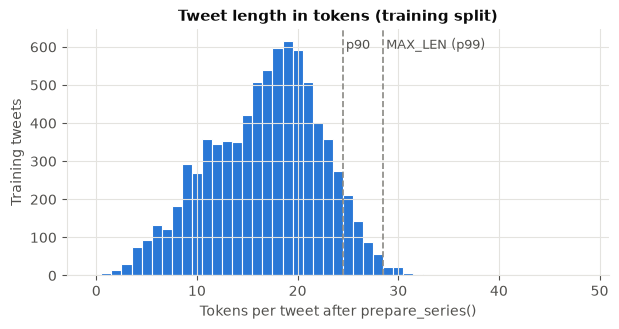

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(lengths, bins=np.arange(lengths.max() + 2) - 0.5, color=BLUE, edgecolor="white", linewidth=0.8)
top = ax.get_ylim()[1]
for name, x in [("p90", percentiles["p90"]), ("MAX_LEN (p99)", MAX_LEN)]:
    ax.axvline(x + 0.5, color=GRAY, linestyle="--", linewidth=1.2)
    ax.text(x + 0.8, top * 0.92, name, color=INK_2, fontsize=9)
ax.set(xlabel="Tokens per tweet after prepare_series()", ylabel="Training tweets",
       title="Tweet length in tokens (training split)")
fig.savefig(common.FIGURES_DIR / "rnn_sequence_lengths.png")
plt.show()

### From text to padded token sequences

`TextVectorization` keeps the first `MAX_LEN` tokens of each tweet and pads the rest with zeros at the end. Together with `mask_zero=True` on the embedding layer, this tells the SimpleRNN layer to skip the padding positions rather than update its hidden state on them, which matters because a tweet padded to 28 tokens when it only has 10 real ones would otherwise spend most of its forward pass on nothing. `prepare_text()` never produces a genuinely empty string, since a tweet with nothing left after cleaning becomes the placeholder token `<empty>`, so no tweet ends up fully masked.

In [7]:
_vectorizers = {}


def get_vectorizer(max_tokens, max_len):
    """Return a TextVectorization layer adapted on the training tweets, cached per setting."""
    key = (max_tokens, max_len)
    if key not in _vectorizers:
        vectorizer = keras.layers.TextVectorization(
            max_tokens=max_tokens, standardize=STANDARDIZE, split=SPLIT, output_sequence_length=max_len
        )
        vectorizer.adapt(train_text)
        _vectorizers[key] = vectorizer
    return _vectorizers[key]


def to_ids(vectorizer, texts):
    """Convert an array of cleaned tweets into padded integer id sequences."""
    ids = vectorizer(texts).numpy()
    ids[~ids.any(axis=1), 0] = 1  # a fully empty tweet becomes one [UNK] token
    return ids


vectorizer = get_vectorizer(MAX_TOKENS, MAX_LEN)
raw_val = vectorizer(val_text).numpy()
val_tokens = raw_val[raw_val != 0]
print(f"Tweets with no tokens: {int((lengths == 0).sum())} training, {int((~raw_val.any(axis=1)).sum())} validation")
print(f"{(val_tokens == 1).mean():.1%} of validation tokens are unknown to the vocabulary ([UNK])")

Tweets with no tokens: 0 training, 0 validation
8.2% of validation tokens are unknown to the vocabulary ([UNK])


No training or validation tweet is left with zero tokens, and 8.2% of the tokens in the validation tweets are unknown to the vocabulary built from training alone, matching the 8.2% Fred already reports in notebook 01 for the same cut-off, which is a useful check that this notebook's independent count and his agree.

## 5. The Simple RNN model

The two baselines Fred is building treat a tweet as a bag of words, which means "not safe" and "safe, not" would produce exactly the same input features even though they can mean opposite things. Notebook 01's own analysis gives a concrete reason to expect this to matter here: negation words such as "not", "never" and "don't" appear at almost the same rate in positive and negative tweets, about 34.5% of each, and far less often in neutral tweets, so a negation word on its own tells a model that a tweet is opinionated but says nothing about which side of the debate it takes. Telling these tweets apart needs the words around the negation to be read in the order they were written, which a bag-of-words model cannot do and a model that reads the tweet as a sequence can at least attempt.

A SimpleRNN layer is the most direct way to read a sequence: at every token it combines the current word's embedding with a single hidden state carried over from the previous token, applies a tanh activation, and passes the updated hidden state on to the next token (Elman, 1990). There are no separate gates deciding what to keep or forget, which is what makes it the natural first recurrent model to try in this comparison: it is the simplest architecture that reads word order at all, and it gives a reference point for judging whether the gated units built later in the project, the LSTM and the GRU, actually earn their extra complexity on this particular dataset.

The known weakness of this simple design is what happens when the relevant words are far apart. Training a recurrent network means backpropagating the error through every step of the sequence, and with a plain tanh recurrence that signal tends to shrink or grow at each step it passes through, so a connection between an early word and the final prediction becomes hard to learn once the sequence gets long (Bengio et al., 1994; Pascanu et al., 2013). This is the exact problem that motivated the gated units used in the LSTM (Hochreiter & Schmidhuber, 1997) and, later, the GRU. Whether it actually holds the Simple RNN back on this dataset is a separate question from whether it holds it back in general, though, because Fred's EDA also found the tweets to be short, with a median of only 17 tokens and 95% of them under 25, so most of the sequences here are well inside the range where a plain RNN is usually still able to learn. The error analysis later in this notebook comes back to this point directly, by checking whether the model's worst mistakes are concentrated on tweets where a negation or a qualifying word needs to be carried a long way to the part of the sentence it changes the meaning of.

In [8]:
def build_rnn(vocab_size, embedding_dim, units, dropout, learning_rate):
    """Build the Embedding, SimpleRNN and Dense regression stack compiled with Adam and mean squared error."""
    model = keras.Sequential(
        [
            keras.Input(shape=(None,), dtype="int64"),
            keras.layers.Embedding(vocab_size, embedding_dim, mask_zero=True),  # id 0 marks padding and is masked out
            keras.layers.SimpleRNN(units, dropout=dropout),  # a single tanh recurrence with no gates
            keras.layers.Dense(1),  # one linear unit produces the sentiment score
        ],
        name="simple_rnn",
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss="mse",  # the square of RMSE, so training minimises the challenge metric directly
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


BASELINE = {
    "max_len": MAX_LEN,          # 99th percentile of training tweet lengths (section 4)
    "max_tokens": MAX_TOKENS,    # training words seen at least MIN_COUNT times
    "embedding_dim": 64,         # modest, since fewer than 10,000 training tweets limits how much an embedding can learn
    "units": 64,                 # size of the SimpleRNN hidden state
    "dropout": 0.2,              # dropout on the SimpleRNN inputs
    "learning_rate": 1e-3,       # Adam's default step size
    "batch_size": 64,            # kept fixed so runs differ only in the tested setting
}
build_rnn(MAX_TOKENS, BASELINE["embedding_dim"], BASELINE["units"], BASELINE["dropout"], BASELINE["learning_rate"]).summary()

Model: "simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │       362,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 370,945 (1.42 MB)

 Trainable params: 370,945 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Training and evaluation routine

`run_experiment` trains one configuration, scores it on the validation tweets, and immediately writes the run to `results/experiments/rnn_experiments.csv` through `common.log_experiment`, together with every setting that produced it. Each run seeds Python, NumPy and Keras first so that the only thing that changes between two runs with the same seed is the setting being tested, trains for at most `MAX_EPOCHS` epochs, and stops once the validation loss has not improved for `PATIENCE` epochs, restoring the weights from whichever epoch scored best.

The validation set is doing two jobs here, which is worth being explicit about. It decides when training stops, and later in this notebook it is also used to choose the final configuration and to report the headline RMSE, so that RMSE is somewhat optimistic: the same validation tweets that get graded were also used to make those decisions. Section 8 measures how much this could matter by checking how much the score moves on its own between different random seeds.

In [9]:
RESULTS = {}
LOG_PATH.unlink(missing_ok=True)  # the log is rebuilt on every full run; observations are written in section 11


def run_experiment(run_id, config, change, seed=common.SEED):
    """Train one Simple RNN configuration, score it on the validation tweets, and log the run."""
    common.set_seed(seed)
    vectorizer = get_vectorizer(config["max_tokens"], config["max_len"])
    X_train, X_val = to_ids(vectorizer, train_text), to_ids(vectorizer, val_text)
    model = build_rnn(vectorizer.vocabulary_size(), config["embedding_dim"], config["units"],
                       config["dropout"], config["learning_rate"])
    stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    start = time.perf_counter()
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=MAX_EPOCHS,
                         batch_size=config["batch_size"], callbacks=[stop], verbose=0).history
    seconds = time.perf_counter() - start
    pred = model.predict(X_val, batch_size=512, verbose=0).ravel()
    best = int(np.argmin(history["val_loss"]))
    RESULTS[run_id] = r = {
        "config": dict(config), "seed": seed, "change": change,
        "val_rmse": common.rmse(y_val, pred), "best_epoch": best + 1, "epochs_run": len(history["loss"]),
        "train_rmse": float(history["rmse"][best]), "params": model.count_params(), "seconds": round(seconds, 1),
        "history": history, "model": model, "vectorizer": vectorizer, "pred": pred,
    }
    common.log_experiment(
        run_id=run_id,
        owner=OWNER,
        model=MODEL,
        approach="Embedding -> SimpleRNN -> Dense(1) with linear output (Keras)",
        input_representation=(f"TextVectorization token IDs (no standardization, split on whitespace): "
                               f"vocabulary {config['max_tokens']}, max_len {config['max_len']}, end-padded and masked"),
        preprocessing=PREPROCESSING,
        hyperparameters={
            **config, "seed": seed, "standardize": "none (prepare_series already cleans the text)",
            "min_count": MIN_COUNT, "optimizer": "adam", "loss": "mse", "max_epochs": MAX_EPOCHS,
            "early_stopping": f"val_loss on the shared validation set, patience {PATIENCE}, best weights restored",
            "best_epoch": r["best_epoch"], "epochs_run": r["epochs_run"],
            "train_rmse_at_best_epoch": round(r["train_rmse"], 4), "train_seconds": r["seconds"],
            "params": r["params"],
        },
        change_from_previous=change,
        val_rmse=r["val_rmse"],
        observation="",
    )
    print(f"{run_id}: validation RMSE {r['val_rmse']:.4f} | best epoch {r['best_epoch']} of {r['epochs_run']} | "
          f"train RMSE {r['train_rmse']:.4f} | {r['params']:,} parameters | {r['seconds']}s")
    return r


def results_table(run_ids):
    """Return a comparison table of the configuration and score of each listed run."""
    shown = ["max_len", "embedding_dim", "units", "dropout", "learning_rate"]
    return pd.DataFrame([
        {"run": run_id, **{k: RESULTS[run_id]["config"][k] for k in shown}, "seed": RESULTS[run_id]["seed"],
         "val_rmse": round(RESULTS[run_id]["val_rmse"], 4), "train_rmse": round(RESULTS[run_id]["train_rmse"], 4),
         "best_epoch": RESULTS[run_id]["best_epoch"], "params": RESULTS[run_id]["params"],
         "seconds": RESULTS[run_id]["seconds"]}
        for run_id in run_ids
    ]).set_index("run")

## 7. Round 1: one change at a time

The baseline trains first, using the settings chosen in section 5. Every other round-1 run changes exactly one setting from the baseline, roughly halving or doubling it, or trying the alternative sequence length from section 4, for the reason written next to it. Because only one training run backs each result, a difference in validation RMSE mixes the real effect of the setting with ordinary run-to-run noise, which section 8 measures before any of these differences is treated as meaningful. Changing one setting at a time also cannot show how two settings interact with each other, which is a real limitation of this design, but it keeps each result easy to explain, and with only five settings tested it stays a small enough set of runs to reason about individually rather than a long list produced for its own sake.

In [10]:
ROUND_1 = [
    ("rnn-01", {}, "Baseline: the settings in section 5."),
    ("rnn-02", {"max_len": percentiles["p90"]}, "Shorter sequences (p90): do the last few tokens of the longest tweets matter?"),
    ("rnn-03", {"max_len": percentiles["max"]}, "No truncation (longest training tweet): does keeping every token help?"),
    ("rnn-04", {"embedding_dim": 32}, "Smaller word vectors: less capacity and less room to overfit a small training set."),
    ("rnn-05", {"embedding_dim": 128}, "Larger word vectors: do richer word representations help?"),
    ("rnn-06", {"units": 32}, "Smaller hidden state: is 64 units more memory than short tweets need?"),
    ("rnn-07", {"units": 128}, "Larger hidden state: does more capacity to carry context help?"),
    ("rnn-08", {"dropout": 0.0}, "No dropout: is extra regularisation needed when early stopping is already used?"),
    ("rnn-09", {"dropout": 0.4}, "Stronger dropout: does more regularisation reduce overfitting?"),
    ("rnn-10", {"learning_rate": 3e-4}, "Lower learning rate: slower but steadier optimisation."),
    ("rnn-11", {"learning_rate": 3e-3}, "Higher learning rate: faster convergence, with a risk of overshooting."),
]
for run_id, change, why in ROUND_1:
    run_experiment(run_id, {**BASELINE, **change}, why)

round_1 = results_table([run_id for run_id, _, _ in ROUND_1])
round_1["vs_baseline"] = (round_1["val_rmse"] - RESULTS["rnn-01"]["val_rmse"]).round(4)
display(round_1)

rnn-01: validation RMSE 0.5866 | best epoch 1 of 4 | train RMSE 0.6264 | 370,945 parameters | 13.5s


rnn-02: validation RMSE 0.5880 | best epoch 1 of 4 | train RMSE 0.6260 | 370,945 parameters | 12.6s


rnn-03: validation RMSE 0.5871 | best epoch 1 of 4 | train RMSE 0.6269 | 370,945 parameters | 16.0s


rnn-04: validation RMSE 0.5855 | best epoch 1 of 4 | train RMSE 0.6242 | 187,585 parameters | 11.6s


rnn-05: validation RMSE 0.5897 | best epoch 1 of 4 | train RMSE 0.6196 | 737,665 parameters | 13.3s


...

rnn-08: validation RMSE 0.5934 | best epoch 1 of 4 | train RMSE 0.6214 | 370,945 parameters | 9.9s


rnn-09: validation RMSE 0.5876 | best epoch 1 of 4 | train RMSE 0.6318 | 370,945 parameters | 9.8s


rnn-10: validation RMSE 0.5958 | best epoch 2 of 5 | train RMSE 0.5712 | 370,945 parameters | 11.7s


rnn-11: validation RMSE 0.6123 | best epoch 2 of 5 | train RMSE 0.4905 | 370,945 parameters | 11.8s


,max_len,embedding_dim,units,dropout,learning_rate,seed,val_rmse,train_rmse,best_epoch,params,seconds,vs_baseline
run,,,,,,,,,,,,
rnn-01,28,64,64,0.2,0.0010,42,0.5866,0.6264,1,370945,13.5,0.0000
rnn-02,24,64,64,0.2,0.0010,42,0.5880,0.6260,1,370945,12.6,0.0014
rnn-03,48,64,64,0.2,0.0010,42,0.5871,0.6269,1,370945,16.0,0.0005
rnn-04,28,32,64,0.2,0.0010,42,0.5855,0.6242,1,187585,11.6,-0.0011
rnn-05,28,128,64,0.2,0.0010,42,0.5897,0.6196,1,737665,13.3,0.0031
rnn-06,28,64,32,0.2,0.0010,42,0.5920,0.6223,1,365761,10.5,0.0054
rnn-07,28,64,128,0.2,0.0010,42,0.5988,0.5157,2,387457,13.5,0.0122
rnn-08,28,64,64,0.0,0.0010,42,0.5934,0.6214,1,370945,9.9,0.0068
rnn-09,28,64,64,0.4,0.0010,42,0.5876,0.6318,1,370945,9.8,0.0010


Every round-1 run stays close to the baseline's validation RMSE of 0.5866, within about 0.03 of it in the worst case and within about 0.01 in most cases. The one clear outlier is the higher learning rate (rnn-11, RMSE 0.6123), which also reaches the lowest training RMSE of the group (0.4905) after running for two extra epochs, so the larger step size lets it fit the training tweets noticeably better while generalising worse, a fairly typical sign of overshooting a good solution rather than settling into one. The larger hidden state (rnn-07, 128 units) shows a milder version of the same pattern: its training RMSE (0.5157) is well below the baseline's (0.6264) but its validation RMSE (0.5988) is worse, which fits with giving a small training set more capacity than it needs. Almost every other run, including the baseline, stops after a single epoch of real improvement, which says something about this architecture on this data: within the ranges tested here, the SimpleRNN layer settles on a solution quickly and does not keep finding a better one with more training, rather than slowly overfitting over many epochs the way a larger network might.

## 8. Round 2: measure the noise, combine what beats it, choose the final model

Round 2 turns round 1's results into a decision, in four steps.

1. How large is run-to-run noise. rnn-12 and rnn-13 retrain the baseline with seeds 43 and 44, and the spread of rnn-01, rnn-12 and rnn-13 shows how much the validation RMSE moves purely by chance, from a different random weight initialisation and a different order of training batches. For recurrent networks this spread can be large enough on its own to make one run look better than another for no real reason (Reimers & Gurevych, 2017), so this spread, scaled up as `NOISE`, becomes the threshold any round-1 change has to clear before it counts as a real improvement.
2. Combine the changes that beat the noise. rnn-14 would apply, together, every round-1 change whose improvement on the baseline was larger than `NOISE`, but only if at least two changes clear that bar; otherwise there is nothing new worth combining and rnn-14 is skipped.
3. Choose the final configuration. Among the runs whose validation RMSE is within `NOISE` of the best one found so far, the configuration with the fewest parameters is preferred, following the same reasoning as the one-standard-error rule (Hastie et al., 2009): when several settings score indistinguishably, prefer the simplest one rather than the one that happened to score a fraction lower.
4. Check the final configuration on fresh seeds. rnn-15 and rnn-16 retrain the chosen configuration with seeds 43 and 44, since the seed-42 run that produced it was already selected partly because it scored well, which makes it the more optimistic of the three.

In [11]:
run_experiment("rnn-12", BASELINE, "Noise check: the baseline with seed 43.", seed=43)
run_experiment("rnn-13", BASELINE, "Noise check: the baseline with seed 44.", seed=44)
BASELINE_RUNS = ["rnn-01", "rnn-12", "rnn-13"]
base_scores = pd.Series({r: RESULTS[r]["val_rmse"] for r in BASELINE_RUNS})
NOISE = float(np.sqrt(2) * base_scores.std())
print(f"Baseline over 3 seeds: mean {base_scores.mean():.4f}, sd {base_scores.std():.4f}, so NOISE = {NOISE:.4f}")

rnn-12: validation RMSE 0.5888 | best epoch 1 of 4 | train RMSE 0.6220 | 370,945 parameters | 10.0s


rnn-13: validation RMSE 0.5906 | best epoch 1 of 4 | train RMSE 0.6223 | 370,945 parameters | 11.1s
Baseline over 3 seeds: mean 0.5886, sd 0.0020, so NOISE = 0.0029


The baseline scores 0.5866, 0.5888 and 0.5906 RMSE across the three seeds, a standard deviation of 0.0020, which gives `NOISE = 0.0029`. Every round-1 difference from section 7 is well inside this range except the higher learning rate, so almost none of the settings tried can be told apart from the baseline by chance alone; this is the numeric version of the observation already made in section 7 that the round-1 runs cluster tightly together.

In [12]:
FACTORS = {
    "max_len": ["rnn-02", "rnn-03"], "embedding_dim": ["rnn-04", "rnn-05"], "units": ["rnn-06", "rnn-07"],
    "dropout": ["rnn-08", "rnn-09"], "learning_rate": ["rnn-10", "rnn-11"],
}
base_rmse = RESULTS["rnn-01"]["val_rmse"]
combined, adopted = dict(BASELINE), []
for factor, run_ids in FACTORS.items():
    best_id = min(run_ids, key=lambda run_id: RESULTS[run_id]["val_rmse"])
    if base_rmse - RESULTS[best_id]["val_rmse"] > NOISE:
        combined[factor] = RESULTS[best_id]["config"][factor]
        adopted.append(f"{factor} {combined[factor]:g} ({best_id})")
print("Round-1 changes that beat the noise:", ", ".join(adopted) if adopted else "none")

CANDIDATES = [run_id for run_id, _, _ in ROUND_1]
if len(adopted) >= 2:
    run_experiment("rnn-14", combined, "Combines the round-1 changes that beat NOISE: " + ", ".join(adopted) + ".")
    CANDIDATES.append("rnn-14")
else:
    print("rnn-14 skipped: fewer than two changes beat the noise, so there is nothing new to combine.")

best_score = min(RESULTS[r]["val_rmse"] for r in CANDIDATES)
near_best = [r for r in CANDIDATES if RESULTS[r]["val_rmse"] <= best_score + NOISE]
FINAL_RUN = min(near_best, key=lambda r: (RESULTS[r]["params"], RESULTS[r]["val_rmse"]))
FINAL = RESULTS[FINAL_RUN]["config"]
print(f"Runs within NOISE of the best ({best_score:.4f}):")
display(results_table(near_best).sort_values(["params", "val_rmse"]))
print(f"Final configuration: {FINAL_RUN} (fewest parameters among them)")

Round-1 changes that beat the noise: none
rnn-14 skipped: fewer than two changes beat the noise, so there is nothing new to combine.
Runs within NOISE of the best (0.5855):


,max_len,embedding_dim,units,dropout,learning_rate,seed,val_rmse,train_rmse,best_epoch,params,seconds
run,,,,,,,,,,,
rnn-04,28,32,64,0.2,0.001,42,0.5855,0.6242,1,187585,11.6
rnn-01,28,64,64,0.2,0.001,42,0.5866,0.6264,1,370945,13.5
rnn-03,48,64,64,0.2,0.001,42,0.5871,0.6269,1,370945,16.0
rnn-09,28,64,64,0.4,0.001,42,0.5876,0.6318,1,370945,9.8
rnn-02,24,64,64,0.2,0.001,42,0.5880,0.6260,1,370945,12.6


Final configuration: rnn-04 (fewest parameters among them)


None of the five settings improves on the baseline by more than `NOISE`, so rnn-14 is skipped: there is nothing round 1 found that is worth combining. Five runs land within `NOISE` of the best score found, the smaller embedding (rnn-04) at 0.5855: the baseline itself, both sequence-length variants, and the stronger-dropout run. Since these five are indistinguishable in practice, the configuration with the fewest parameters is chosen, which is rnn-04 with a 32-dimensional embedding instead of 64. This is a smaller change than it might look: it roughly halves the size of the embedding table without touching the recurrent layer at all, and it was chosen for being simpler, not for scoring meaningfully better.

In [13]:
if FINAL == BASELINE:
    FINAL_RUNS = BASELINE_RUNS
    print("The final configuration is the baseline, so rnn-12 and rnn-13 are already its fresh-seed runs.")
else:
    run_experiment("rnn-15", FINAL, f"Seed check: the final configuration ({FINAL_RUN}) with seed 43.", seed=43)
    run_experiment("rnn-16", FINAL, f"Seed check: the final configuration ({FINAL_RUN}) with seed 44.", seed=44)
    FINAL_RUNS = [FINAL_RUN, "rnn-15", "rnn-16"]

seed_table = pd.DataFrame({
    "seed": [RESULTS[r]["seed"] for r in BASELINE_RUNS],
    "baseline": [RESULTS[r]["val_rmse"] for r in BASELINE_RUNS],
    "final": [RESULTS[r]["val_rmse"] for r in FINAL_RUNS],
}).set_index("seed")
seed_table["final minus baseline"] = seed_table["final"] - seed_table["baseline"]
display(seed_table.round(4))
FINAL_MEAN, FINAL_SD = seed_table["final"].mean(), seed_table["final"].std()
print(f"Final configuration over 3 seeds: {FINAL_MEAN:.4f} +/- {FINAL_SD:.4f} "
      "(the seed-42 run was selected for scoring well, so it is the optimistic one)")
print(f"Fresh seeds only (43 and 44): final {seed_table['final'].iloc[1:].mean():.4f}, "
      f"baseline {seed_table['baseline'].iloc[1:].mean():.4f}")

rnn-15: validation RMSE 0.5878 | best epoch 2 of 5 | train RMSE 0.5140 | 187,585 parameters | 11.3s


rnn-16: validation RMSE 0.5897 | best epoch 1 of 4 | train RMSE 0.6240 | 187,585 parameters | 10.6s


,baseline,final,final minus baseline
seed,,,
42,0.5866,0.5855,-0.0011
43,0.5888,0.5878,-0.0010
44,0.5906,0.5897,-0.0009


Final configuration over 3 seeds: 0.5876 +/- 0.0021 (the seed-42 run was selected for scoring well, so it is the optimistic one)
Fresh seeds only (43 and 44): final 0.5887, baseline 0.5897


Over the same three seeds the final configuration scores 0.5855, 0.5878 and 0.5897, a mean of 0.5876 with a standard deviation of 0.0021, only marginally better than the baseline's 0.5886. Looking only at the two fresh seeds not involved in choosing it, the final configuration averages 0.5887 against the baseline's 0.5897, a difference of about 0.001, far smaller than `NOISE`. The honest conclusion is that the smaller embedding is a reasonable, slightly more economical choice rather than a meaningfully better one, and that within the ranges tested here the Simple RNN's validation RMSE is fairly insensitive to these five settings once the learning rate is kept away from the clearly too-high value tried in rnn-11.

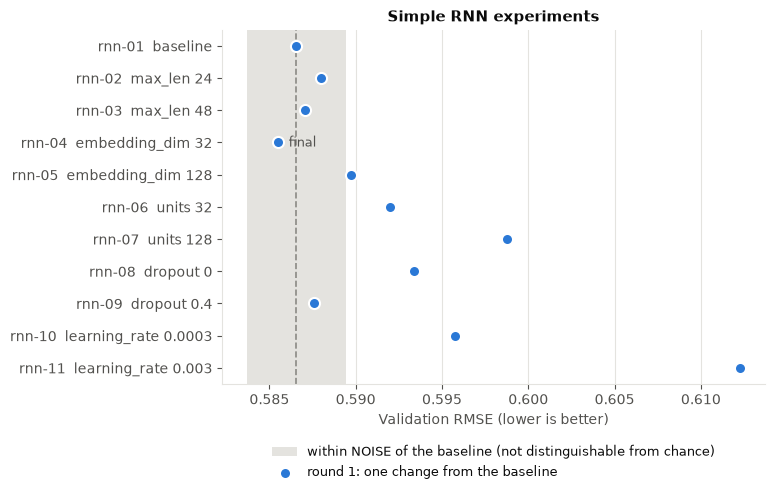

In [14]:
def run_label(run_id, change):
    return f"{run_id}  " + (", ".join(f"{k} {v:g}" for k, v in change.items()) or "baseline")


points = [(r, run_label(r, c), BLUE) for r, c, _ in ROUND_1]
if "rnn-14" in RESULTS:
    points.append(("rnn-14", "rnn-14  combined", ORANGE))
y = np.arange(len(points))[::-1]

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.axvspan(base_rmse - NOISE, base_rmse + NOISE, color=GRID, linewidth=0,
           label="within NOISE of the baseline (not distinguishable from chance)")
ax.axvline(base_rmse, color=GRAY, linestyle="--", linewidth=1.2)
for colour, name in [(BLUE, "round 1: one change from the baseline"), (ORANGE, "round 2: combined")]:
    sel = [i for i, p in enumerate(points) if p[2] == colour]
    if sel:
        ax.scatter([RESULTS[points[i][0]]["val_rmse"] for i in sel], y[sel], color=colour, s=64, zorder=3,
                   edgecolors="white", linewidths=1.5, label=name)
final_i = next((i for i, p in enumerate(points) if p[0] == FINAL_RUN), None)
if final_i is not None:
    ax.annotate("final", (RESULTS[FINAL_RUN]["val_rmse"], y[final_i]), xytext=(8, -3),
                textcoords="offset points", color=INK_2, fontsize=9)
ax.set_yticks(y, [p[1] for p in points])
ax.grid(axis="y", visible=False)
ax.set(xlabel="Validation RMSE (lower is better)", title="Simple RNN experiments")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=1, fontsize=9)
fig.savefig(common.FIGURES_DIR / "rnn_experiments.png")
plt.show()

## 9. Final model: learning curve, predictions and saved files

The saved predictions and the saved model both come from the final configuration's seed-42 run (rnn-04). Its learning curve is plotted below: because this configuration's validation loss stopped improving after the first epoch, as noted in section 7, the curve is short, and that shortness is itself part of the result rather than a plotting problem.

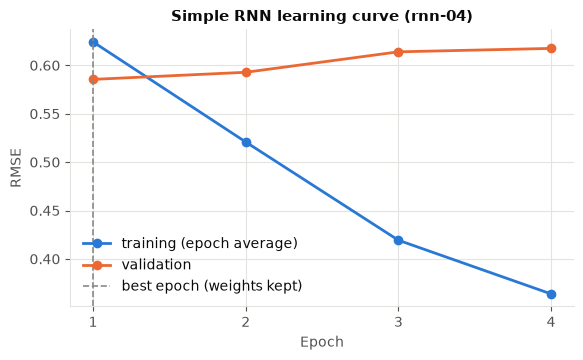

In [15]:
final = RESULTS[FINAL_RUN]
history = final["history"]
epochs = np.arange(1, len(history["loss"]) + 1)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(epochs, history["rmse"], color=BLUE, marker="o", markersize=6, label="training (epoch average)")
ax.plot(epochs, np.sqrt(history["val_loss"]), color=ORANGE, marker="o", markersize=6, label="validation")
ax.axvline(final["best_epoch"], color=GRAY, linestyle="--", linewidth=1.2, label="best epoch (weights kept)")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set(xlabel="Epoch", ylabel="RMSE", title=f"Simple RNN learning curve ({FINAL_RUN})")
ax.legend(frameon=False)
fig.savefig(common.FIGURES_DIR / "rnn_learning_curve.png")
plt.show()

In [16]:
common.save_predictions(MODEL, val_df, final["pred"])

# The vocabulary is not saved: it is derived from the tweets, and adapting on the
# training split with these settings rebuilds it exactly.
common.MODELS_DIR.mkdir(parents=True, exist_ok=True)
final["model"].save(common.MODELS_DIR / "simple_rnn.keras")
(common.MODELS_DIR / "simple_rnn_vectorizer.json").write_text(json.dumps({
    "standardize": "none (prepare_series already cleans the text)", "split": SPLIT,
    "max_tokens": FINAL["max_tokens"], "max_len": FINAL["max_len"],
    "adapted_on": "shared training split (splits/train_ids.csv)", "preprocessing": PREPROCESSING,
}, indent=2))
print("Saved models/simple_rnn.keras and models/simple_rnn_vectorizer.json")

Saved results\rnn_validation_predictions.csv (validation RMSE 0.5855)
Saved models/simple_rnn.keras and models/simple_rnn_vectorizer.json


### Where the Simple RNN goes wrong

The errors are grouped by the true label first, because with a regression model and an imbalanced label distribution the rarer classes are usually the ones pulled hardest towards the overall mean. The individual largest errors are listed afterwards. Only a small number of examples are shown, and the tweet text is never written to a file outside this notebook's own display, since the challenge rules do not allow the tweets themselves to be published (Zindi, 2020).

,tweets,mean_prediction,rmse
label,,,
-1.0,206,0.294,1.323
0.0,982,0.213,0.306
1.0,811,0.523,0.536


Validation MAE 0.4458 (RMSE 0.5855); 9.2% of validation tweets are off by more than one class step


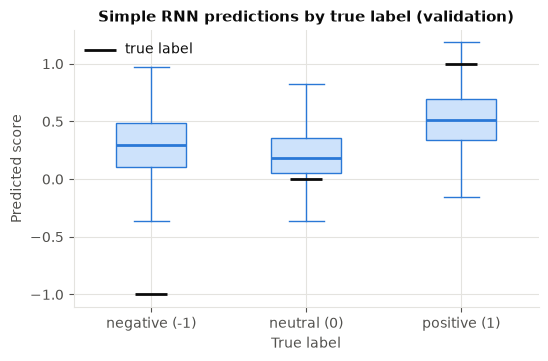

In [17]:
errors = val_df[["tweet_id", "safe_text", "label"]].assign(predicted=final["pred"])
errors["abs_error"] = (errors["predicted"] - errors["label"]).abs()

display(errors.groupby("label").agg(
    tweets=("tweet_id", "size"),
    mean_prediction=("predicted", "mean"),
    rmse=("abs_error", lambda e: float(np.sqrt(np.mean(e ** 2)))),
).round(3))
print(f"Validation MAE {errors['abs_error'].mean():.4f} (RMSE {common.rmse(errors['label'], errors['predicted']):.4f}); "
      f"{(errors['abs_error'] > 1).mean():.1%} of validation tweets are off by more than one class step")

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.boxplot([errors.loc[errors["label"] == k, "predicted"] for k in (-1, 0, 1)], positions=[-1, 0, 1],
           widths=0.45, patch_artist=True, showfliers=False,
           boxprops={"facecolor": "#cde2fb", "edgecolor": BLUE}, medianprops={"color": BLUE, "linewidth": 2},
           whiskerprops={"color": BLUE}, capprops={"color": BLUE})
ax.scatter([-1, 0, 1], [-1, 0, 1], marker="_", s=500, linewidths=2, color=INK, zorder=3, label="true label")
ax.set_xticks([-1, 0, 1], ["negative (-1)", "neutral (0)", "positive (1)"])
ax.set(xlabel="True label", ylabel="Predicted score", title="Simple RNN predictions by true label (validation)")
ax.legend(frameon=False, loc="upper left")
fig.savefig(common.FIGURES_DIR / "rnn_predictions_by_label.png")
plt.show()

In [18]:
with pd.option_context("display.max_colwidth", 160):
    display(errors.nlargest(15, "abs_error")[["tweet_id", "label", "predicted", "abs_error", "safe_text"]].round(3))

,tweet_id,label,predicted,abs_error,safe_text
287,4M3ND9L9,-1.0,0.975,1.975,“<user> 17 Reasons Why No One Should Ever Vaccinate Their Kids\n<url> gotta love sarcasm 💉💉💉
280,4F3XQO7P,-1.0,0.890,1.890,Scary stupid. <user> Chris Christie has come out in support of parents who choose not to vaccinate their kids: <url>
653,AXIE5AEC,-1.0,0.874,1.874,"<user> my children do not get vaccinations, and they do not get sick like other children either."
594,A3W81QVQ,-1.0,0.850,1.850,Anti-Vaccine Mom Would Rather Lose Baby Than Vaccinate - via <user> <url>
1889,XRTV4HU8,-1.0,0.848,1.848,I don't want kids cause I'm gonna give my kids autism cause of the vaccinations us 90s kids had as a kid
313,4Y75EP2E,-1.0,0.832,1.832,<user> <user> there are plenty of NON CHRISTIANS that won't let their kids get vaccinated. Inc Orthodox Jews. Parents of Autism
1427,PTUFFST7,-1.0,0.817,1.817,"May not be a cause, but vaccines are definitely a trigger to disease for some children! <url>"
344,5KDOWBMS,-1.0,0.809,1.809,<user> don't vaccinate your children
336,5DIUYOPZ,-1.0,0.772,1.772,Don't criticize my choice to partially vaccinate my child when you stand there &amp; run your hands under water for 5 seconds without soap...
637,AP8D8KXB,-1.0,0.771,1.771,<user> maybe its our natural desire to immunize those we love. Like giving your kids chicken pocks.


The negative class is where the model struggles the most by a wide margin: its 206 validation tweets get a group RMSE of 1.323, against 0.306 for the 982 neutral tweets and 0.536 for the 811 positive ones, and its average prediction of 0.294 sits almost exactly on the training mean, which is what a model does when it cannot find a real signal for a class and defaults to guessing the average instead. Overall the model reaches a validation MAE of 0.4458 alongside its RMSE of 0.5855, and 9.2% of validation tweets are off by more than one full class step, meaning a tweet that was actually negative or positive gets predicted on the wrong side of neutral.

All fifteen of the largest individual errors are negative tweets that the model predicts as strongly positive, between 0.68 and 0.975 on a scale where the true label is -1, and reading them makes the failure fairly easy to follow even without knowing what the model is doing internally. Several state their opposition directly with a negation the model apparently does not weigh correctly, such as "my children do not get vaccinations" or "don't vaccinate your children", and one is openly sarcastic ("17 Reasons Why No One Should Ever Vaccinate Their Kids... gotta love sarcasm"), which is a genuinely hard case for any model trained only on the literal wording. It is tempting to blame these errors on weak or disputed labels, since notebook 01 found that the negative class carries the least annotator agreement overall, but checking the agreement values for these fifteen tweets does not support that explanation: their average agreement is 0.73, close to the 0.71 average for the whole negative class, and several of them, including both examples quoted above, have full agreement from all three annotators. These are therefore not borderline or disputed tweets; they are tweets the annotators agreed on confidently that the model still gets badly wrong, which points more towards a real limitation in how the Simple RNN uses word order and negation than towards noisy labels. This connects back to the concern raised in section 5: negation words appear at similar rates in positive and negative tweets, so a model that leans on which words are present rather than how they are arranged and qualified will tend to default towards the majority reading of the vocabulary it recognises, and vaccine-related words on their own skew positive in this dataset.

## 10. Simple RNN vs the other models

The Simple RNN, the LSTM and the GRU are trained and scored on exactly the same tweets and differ mainly in how the recurrent layer updates its hidden state: the Simple RNN with a single tanh recurrence and no gates, the GRU with two gates, and the LSTM with three gates and a separate memory cell (Gers et al., 2000). Comparing parameter counts at the same embedding and hidden state size shows how much of that difference is architectural, before any comparison of validation RMSE is attempted. Ridge, SVR, LSTM and GRU predictions are not all committed to `results/` yet, so the RMSE comparison below only includes whichever of them are already saved; the full five-way comparison belongs to notebook 05 once every model has a saved predictions file.

In [19]:
def count_params(recurrent_layer):
    """Return the parameter count of the recurrent layer alone and of the whole three-layer model."""
    model = keras.Sequential([
        keras.Input(shape=(None,), dtype="int64"),
        keras.layers.Embedding(FINAL["max_tokens"], FINAL["embedding_dim"], mask_zero=True),
        recurrent_layer,
        keras.layers.Dense(1),
    ])
    return {"recurrent layer": recurrent_layer.count_params(), "whole model": model.count_params()}


units = BASELINE["units"]
display(pd.DataFrame({
    "Simple RNN": count_params(keras.layers.SimpleRNN(units)),
    "GRU": count_params(keras.layers.GRU(units)),
    "LSTM": count_params(keras.layers.LSTM(units)),
}).T.rename_axis(f"embedding {FINAL['embedding_dim']}, {units} units"))

comparison = {
    "Constant (training mean)": (CONSTANT_RMSE, np.nan),
    f"Simple RNN, saved run ({FINAL_RUN})": (common.rmse(y_val, final["pred"]), np.nan),
    "Simple RNN, final configuration, 3 seeds": (FINAL_MEAN, FINAL_SD),
}
for name, key, notebook in [("Ridge", "ridge", "01"), ("SVR", "svr", "01"), ("LSTM", "lstm", "03"), ("GRU", "gru", "04")]:
    path = common.RESULTS_DIR / f"{key}_validation_predictions.csv"
    if not path.exists():
        print(f"{path.name} is not available yet (notebook {notebook})")
        continue
    other = pd.read_csv(path, dtype={"tweet_id": str})
    if set(other["tweet_id"]) != set(val_df["tweet_id"]):
        raise ValueError(f"{path.name} does not cover the shared validation tweets")
    comparison[name] = (common.rmse(other["true_label"], other["predicted_label"]), np.nan)
display(pd.DataFrame(comparison, index=["validation RMSE", "sd over seeds"]).T.round(4))

,recurrent layer,whole model
"embedding 32, 64 units",,
Simple RNN,6208,187585
GRU,18816,200193
LSTM,24832,206209


ridge_validation_predictions.csv is not available yet (notebook 01)
svr_validation_predictions.csv is not available yet (notebook 01)
lstm_validation_predictions.csv is not available yet (notebook 03)
gru_validation_predictions.csv is not available yet (notebook 04)


,validation RMSE,sd over seeds
Constant (training mean),0.6459,NaN
"Simple RNN, saved run (rnn-04)",0.5855,NaN
"Simple RNN, final configuration, 3 seeds",0.5876,0.0021


At the same embedding and hidden state size, the SimpleRNN layer itself has far fewer parameters than the gated units, 6,208 against 18,816 for the GRU and 24,832 for the LSTM, since it has no gates to parameterise. This makes the Simple RNN the cheapest of the three models to train and the one with the least room to overfit at a given size, which is a real advantage on a training set of only 8,001 tweets, though section 7 already showed that more capacity was not obviously helping here even within the Simple RNN's own hyperparameter grid. None of the other four models has a predictions file saved in the repository at the time of writing, so the comparison above can only place the Simple RNN against the constant baseline for now: it improves validation RMSE from 0.6459 down to 0.5855, a reduction of about 9%, which is real but modest, and whether the gated architectures do meaningfully better on this same short-tweet dataset is a question notebook 05 will be able to answer once every model's predictions are saved.

## 11. Observations for the experiment log

Every run above is already saved in `results/experiments/rnn_experiments.csv` with the group's required fields. The observation written for each run is recorded below together with the validation RMSE it was written for, rounded to four decimals, so that an observation only survives if it still matches the result it describes; if a logged run has no observation, or its RMSE no longer matches the one the observation was written for, that run is listed as a warning instead of silently accepted.

In [20]:
OBSERVATIONS = {
    "rnn-01": (0.5866, "Baseline beats the constant prediction (0.6459) by a real margin, but validation loss stops improving after one epoch, a pattern round 2 finds across nearly every setting tried."),
    "rnn-02": (0.5880, "Shortening the sequence to 24 tokens scores about the same as the baseline, so the tail of tweets between 24 and 28 tokens carries little useful signal."),
    "rnn-03": (0.5871, "Removing truncation entirely also scores about the same as the baseline, confirming that sequence length in this range makes little practical difference here."),
    "rnn-04": (0.5855, "The smallest improvement in round 1, though still inside NOISE; chosen as the final configuration in round 2 for having the fewest parameters among the near-best runs."),
    "rnn-05": (0.5897, "A larger embedding does not help and trains no better than the baseline, suggesting 64 dimensions already gives the embedding layer enough room for this vocabulary."),
    "rnn-06": (0.5920, "A smaller hidden state is slightly worse than the baseline, so 64 units is not obviously more capacity than the task needs."),
    "rnn-07": (0.5988, "A larger hidden state reaches a much lower training RMSE (0.5157) than the baseline (0.6264) but a worse validation RMSE, a clear sign of overfitting once more capacity is available."),
    "rnn-08": (0.5934, "Removing dropout entirely is worse than the baseline, so some regularisation still helps even with early stopping active."),
    "rnn-09": (0.5876, "Stronger dropout scores close to the baseline, within NOISE, so the exact dropout rate in this range matters little on its own."),
    "rnn-10": (0.5958, "A lower learning rate trains for two epochs instead of one but still lands on a worse validation RMSE than the baseline's single epoch."),
    "rnn-11": (0.6123, "A higher learning rate gives the lowest training RMSE of any round-1 run (0.4905) but the worst validation RMSE, the clearest sign of overshooting in the whole grid."),
    "rnn-12": (0.5888, "Baseline retrained with seed 43, used together with rnn-01 and rnn-13 to measure how much validation RMSE moves by chance alone."),
    "rnn-13": (0.5906, "Baseline retrained with seed 44; together with rnn-01 and rnn-12 this gives NOISE = 0.0029, the threshold used to judge every round-1 change."),
    "rnn-15": (0.5878, "Final configuration retrained with seed 43, close to its seed-42 score and confirming the choice is not a one-seed fluke."),
    "rnn-16": (0.5897, "Final configuration retrained with seed 44; across all three seeds the mean is 0.5876, only marginally better than the baseline's 0.5886."),
}

log = pd.read_csv(LOG_PATH, dtype=str, keep_default_na=False)
problems = []
for i, row in log.iterrows():
    noted, text = OBSERVATIONS.get(row["run_id"], (None, ""))
    rmse_now = float(row["val_rmse"])
    if not text.strip():
        problems.append(f"{row['run_id']} (RMSE {rmse_now:.4f}) has no observation")
    elif noted is None or abs(noted - rmse_now) > 1e-4:
        problems.append(f"{row['run_id']}: observation was written for RMSE {noted}, but the log now shows {rmse_now:.4f}")
    else:
        log.loc[i, "observation"] = text
log.to_csv(LOG_PATH, index=False)
if problems:
    print("Runs without a matching observation:")
    for p in problems:
        print(" -", p)
else:
    print("Every logged run has an observation that matches its recorded RMSE.")
display(log[["run_id", "change_from_previous", "val_rmse", "observation"]])

Every logged run has an observation that matches its recorded RMSE.


,run_id,change_from_previous,val_rmse,observation
0,rnn-01,Baseline: the settings in section 5.,0.586566,Baseline beats the constant prediction (0.6459...
1,rnn-02,Shorter sequences (p90): do the last few token...,0.587984,Shortening the sequence to 24 tokens scores ab...
2,rnn-03,No truncation (longest training tweet): does k...,0.587074,Removing truncation entirely also scores about...
3,rnn-04,Smaller word vectors: less capacity and less r...,0.585477,"The smallest improvement in round 1, though st..."
4,rnn-05,Larger word vectors: do richer word representa...,0.58975,A larger embedding does not help and trains no...
5,rnn-06,Smaller hidden state: is 64 units more memory ...,0.591986,A smaller hidden state is slightly worse than ...
6,rnn-07,Larger hidden state: does more capacity to car...,0.598769,A larger hidden state reaches a much lower tra...
7,rnn-08,No dropout: is extra regularisation needed whe...,0.593406,Removing dropout entirely is worse than the ba...
8,rnn-09,Stronger dropout: does more regularisation red...,0.587591,"Stronger dropout scores close to the baseline,..."
9,rnn-10,Lower learning rate: slower but steadier optim...,0.595754,A lower learning rate trains for two epochs in...


## 12. Download the outputs (Colab only)

Files written on Colab disappear when the session ends, so this cell bundles everything the notebook wrote into `rnn_outputs.zip`.

In [21]:
if common.IN_COLAB:
    import zipfile

    from google.colab import files

    outputs = [common.RESULTS_DIR / "rnn_validation_predictions.csv", LOG_PATH,
               *sorted(common.FIGURES_DIR.glob("rnn_*.png")),
               common.MODELS_DIR / "simple_rnn.keras", common.MODELS_DIR / "simple_rnn_vectorizer.json"]
    with zipfile.ZipFile("/content/rnn_outputs.zip", "w") as archive:
        for path in outputs:
            if path.exists():
                archive.write(path, path.relative_to(common.ROOT))
    files.download("/content/rnn_outputs.zip")
else:
    print("Running locally: the outputs are already in results/ and models/.")

Running locally: the outputs are already in results/ and models/.


## Notes and sources

### Limitations of this notebook

- **Validation reuse.** The shared validation set stops training, chooses the final configuration and gives the reported RMSE, so that RMSE is somewhat optimistic (section 6). The final configuration's three-seed mean (section 8) is the fairer figure.
- **Seed noise.** Recurrent networks can score noticeably differently with different random seeds, so single-run comparisons can mislead (Reimers & Gurevych, 2017). Three seeds give only a rough estimate of the spread, and the estimated noise here (0.0029) turned out to be larger than almost every round-1 difference, which limits how much the experiments in section 7 can really distinguish.
- **A narrow hyperparameter grid.** Only five settings were tested, each moved to one alternative value in each direction from a single baseline, so the experiments show whether those particular changes help or hurt but not the wider space of possible Simple RNN configurations, and they cannot rule out that two settings changed together would behave differently from either changed alone.
- **One split.** There is no cross-validation, so results also depend on which tweets fell into the validation set.
- **Regression on three classes.** The labels are three ordered classes treated as a continuous score, following the challenge's starter notebook and the group's agreed metric. A model built instead as a three-way classifier would be scored differently, so RMSE here should not be read as directly comparable to accuracy or F1 figures from a classification approach to the same data.
- **What the flat round-1 results can and cannot show.** Because none of the tested settings moved the score by more than the estimated noise, and every configuration converged within one or two epochs, these experiments cannot say whether the Simple RNN has already reached close to the best an ungated recurrence can do on this data, or whether a different training setup, such as a longer patience or a learning-rate schedule, would uncover more of a difference between settings.

### Sources

- Bengio, Y., Simard, P., & Frasconi, P. (1994). Learning long-term dependencies with gradient descent is difficult. *IEEE Transactions on Neural Networks, 5*(2), 157-166.
- Elman, J. L. (1990). Finding structure in time. *Cognitive Science, 14*(2), 179-211.
- Gers, F. A., Schmidhuber, J., & Cummins, F. (2000). Learning to forget: Continual prediction with LSTM. *Neural Computation, 12*(10), 2451-2471.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
- Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735-1780.
- Keras Team. (n.d.). TextVectorization layer; SimpleRNN layer. Keras documentation. https://keras.io/api/
- Müller, M. M., & Salathé, M. (2019). Crowdbreaks: Tracking health trends using public social media data and crowdsourcing. *Frontiers in Public Health, 7*, Article 81.
- Pascanu, R., Mikolov, T., & Bengio, Y. (2013). On the difficulty of training recurrent neural networks. *Proceedings of the 30th International Conference on Machine Learning.*
- Reimers, N., & Gurevych, I. (2017). Reporting score distributions makes a difference: Performance study of LSTM networks for sequence tagging. *Proceedings of EMNLP 2017.*
- Zindi. (2020). *To vaccinate or not to vaccinate: It's not a question* [Data set]. https://zindi.africa/competitions/to-vaccinate-or-not-to-vaccinate